In [1]:
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = [12, 7.42]

In [3]:
A, omega0, omega, gamma, x0, v0, m = 0.0, 1.0, 0.0, 0.1, 1.0, 0.0, 1.0
t1, h1 = 50.0, 0.01
rk4_color = "#187bed"

In questa relazione andremo a studiare le equazioni del moto di un oscillatore armonico, che rappresenta un modello largamente utilizzato nello studio di sistemi fisici che si trovano vicini ad una posizione di equilibrio stabile. 
In questo caso specifico stiamo considerando un oscillatore armonico in cui è presente una forza di attrito viscoso, e quindi dipendente dalla velocità, e una forzante esterna. Utilizzando la seconda legge della dinamica e includendo una forza elastica ($F_{el}=-kx$), una forza di attrito viscoso proporzionale alla velocità ($F_a=-bv$) e una forzante esterna periodica ($F_{ext}=F_0 \cos(\omega t)$) otteniamo: $$m\ddot{x}=-kx-b\dot{x}+F_0 \cos(\omega t),$$ che dopo una manipolazione algebrica e con l'introduzione della **frequenza naturale dell'oscillatore** ($\omega_0$), del **coefficiente di smorzamento** ($\gamma$) e dell'**ampiezza della forzante** ($A=F_0/m$) diventa: $$\ddot{x}=-\omega^{2}_{0}x - \gamma\dot{x} + A\cos(\omega t).$$

Abbiamo un'equazione differenziale del secondo ordine che possiamo trasformare in un sistema di due equazioni differenziale del primo ordine introducendo la velocità $v=\dot{x}$: $$\dot{x}=v \qquad \land \qquad \dot{v}=-\omega^{2}_{0}x - \gamma v + A\cos(\omega t).$$

Possiamo notare che la forzante dipende dalla velocità e quindi non è possibile utilizzare il metodo di Velocity-Verlet: simuleremo l'oscillatore con il metodo di Runge-Kutta 4, che viene implementato qui di seguito.

In [4]:
def rk4(x0: float, h: float, times: list[float], A: float, omega0: float, omega: float, gamma: float, v0: float) -> tuple[list[float], list[float]]:
    pos, vel = np.zeros(len(times)), np.zeros(len(times))
    pos[0], vel[0] = x0, v0
    
    for i in range(1, len(times)):
        k1x, k1v = vel[i-1], -omega0**2 * pos[i-1] - gamma * vel[i-1] + A * np.cos(omega * times[i])
        k2x, k2v = vel[i-1] + h/2 * k1v, -omega0**2 * (pos[i-1] + 0.5 * h * k1x) - gamma * (vel[i-1] + 0.5 * h * k1v) + A * np.cos(omega * (times[i] + 0.5 * h))
        k3x, k3v = vel[i-1] + h/2 * k2v, -omega0**2 * (pos[i-1] + 0.5 * h * k2x) - gamma * (vel[i-1] + 0.5 * h * k2v) + A * np.cos(omega * (times[i] + 0.5 * h))
        k4x, k4v = vel[i-1] + h * k3v, -omega0**2 * (pos[i-1] + 0.5 * h * k3x) - gamma * (vel[i-1] + 0.5 * h * k3v) + A * np.cos(omega * (times[i] + h))

        pos[i] = pos[i-1] + h/6 * (k1x + 2*k2x + 2*k3x + k4x)
        vel[i] = vel[i-1] + h/6 * (k1v + 2*k2v + 2*k3v + k4v)
        
    return pos, vel

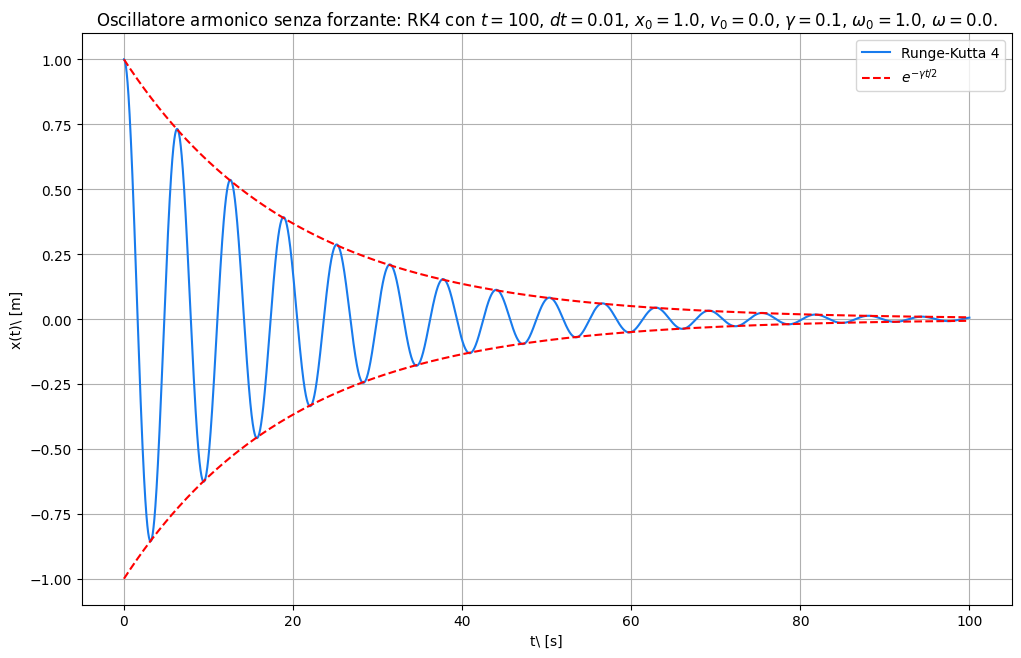

In [48]:
times = np.arange(0, t1, h1)
pos, vel = rk4(x0=x0, h=h1, times=times, A=A, omega0=omega0, omega=omega, gamma=gamma, v0=v0)
plt.plot(times, pos, color=rk4_color, label="Runge-Kutta 4")
plt.plot(times, np.exp(-gamma*times/2), "--", label=r"$e^{-\gamma t/2}$", color="red")
plt.plot(times, -np.exp(-gamma*times/2), "--", color="red")
plt.xlabel(r"t\ [s]")
plt.ylabel(r"x(t)\ [m]")
plt.legend()
plt.grid()
plt.title(fr"Oscillatore armonico senza forzante: RK4 con $t={t1}$, $dt={h1}$, $x_0={x0}$, $v_0={v0}$, $\gamma={gamma}$, $\omega_0={omega0}$, $\omega={omega}$.")
plt.show()

Iniziamo analizzando il caso in assenza di forzante, cioè $A=0$: notiamo che l'ampiezza decade seguendo un andamento esponenziale pari a $exp(-\gamma t/2)$, con $\gamma$ coefficiente di smorzamento.

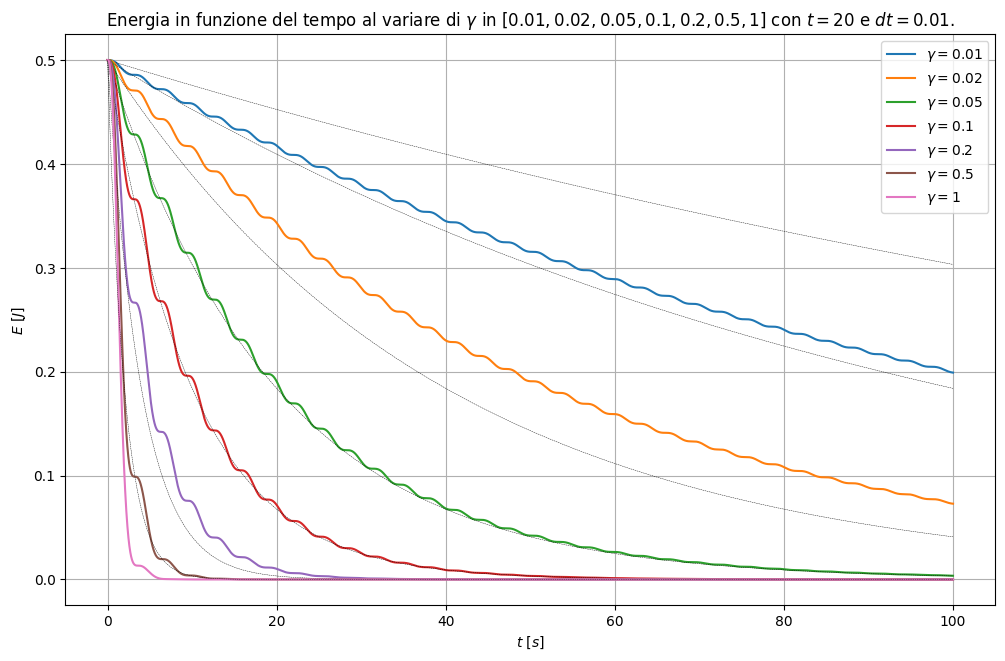

In [49]:
def energy(x: float, v: float, m: float, omega0: float) -> float:
    return 0.5 * m * (v**2 + omega0**2 * x**2)

gs = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1]
for g in gs:
    pos, vel = rk4(x0=x0, h=h1, times=times, A=A, omega0=omega0, omega=omega, gamma=g, v0=v0)
    rk4_energy = energy(x=pos, v=vel, m=m, omega0=omega0)
    plt.plot(times, rk4_energy, label=rf"$\gamma={g}$")
    plt.plot(times, np.exp(-g*times/2)/2, "--", color="black", lw=0.3)
    plt.xlabel(r"$t\ [s]$")
    plt.ylabel(r"$E\ [J]$")

plt.grid()
plt.legend()
plt.title(rf"Energia in funzione del tempo al variare di $\gamma$ in ${gs}$ con $t=20$ e $dt=0.01$.")
plt.show()

Mantenendo lo stesso intervallo temporale studiamo l'andamento dell'energia in assenza di forzante e notiamo che all'aumentare del coefficiente di smorzamento $\gamma$ l'energia decade molto più velocemente: l'andamento segue un esponenziale decrescente e nell'evoluzione oscilla attorno a tale esponenziale.

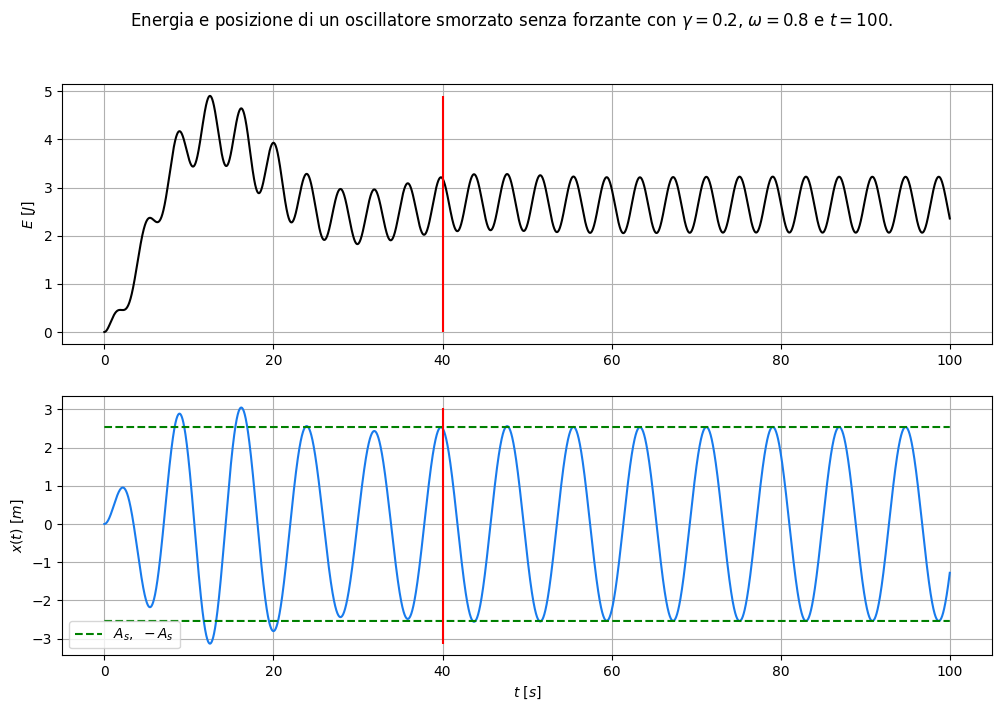

In [46]:
omega01, gamma1, A1, omega1 = 1.0, 0.2, 1.0, 0.8
time_costant = 4*(2/gamma1) # calcolo fine regime transitorio
t1, x01, v01 = 100, 0.0, 0.0
t_1 = np.arange(0, t1, h1)

As = A1 / np.sqrt((omega01**2 - omega1**2)**2 + (gamma1 * omega1)**2)
A_s = np.ones(len(t_1))*As
pos, vel = rk4(x0=x01, h=h1, times=t_1, A=A1, omega0=omega01, omega=omega1, gamma=gamma1, v0=v01)
rk4_energy = energy(x=pos, v=vel, m=m, omega0=omega01)

fig, (ax1, ax2) = plt.subplots(2,1)
ax1.plot(t_1, rk4_energy, color="black")
ax1.set_ylabel(r"$E\ [J]$")
ax1.vlines(time_costant, ymin=np.min(rk4_energy), ymax=np.max(rk4_energy), color="red")
ax1.grid(True)

ax2.plot(t_1, pos, color=rk4_color)
ax2.plot(t_1, A_s, "--", color="green", label=r"$A_s,\ -A_s$")
ax2.plot(t_1, -A_s, "--", color="green")
ax2.set_xlabel(r"$t\ [s]$")
ax2.set_ylabel(r"$x(t)\ [m]$")
ax2.vlines(time_costant, ymin=min(pos), ymax=max(pos), color="red")
ax2.grid(True)
ax2.legend()

fig.suptitle(rf"Energia e posizione di un oscillatore smorzato senza forzante con $\gamma={gamma1}$, $\omega={omega1}$ e $t={t1}$.")
plt.show()

Utilizzando un coefficiente di smorzamento $\gamma$ possiamo individuare una costante di tempo $\tau=2/\gamma$ e congetturare che il regime transitorio dell'oscillazione termini dopo $4\tau$. Nel grafico è stata disegnata una linea rossa verticale in corrispondenza di tale valore ($t=40\ s$) e notiamo che coincide con l'inizio del regime stazionario: l'ampiezza stazionaria teorica calcolata con $$A_s = \frac{A}{\sqrt{(\omega^{2}_{0}-\omega^2)^2 + (\gamma\omega)^2}}$$ è pari a quella numerica.

In [8]:
omegas = np.linspace(0.5, 1.5, 20)
gamma3 = 0.3
time_costant2 = 4*(2/gamma) # calcolo fine regime transitorio
time_costant3 = 4*(2/gamma3)
t_2 = np.arange(0, 200, h1)

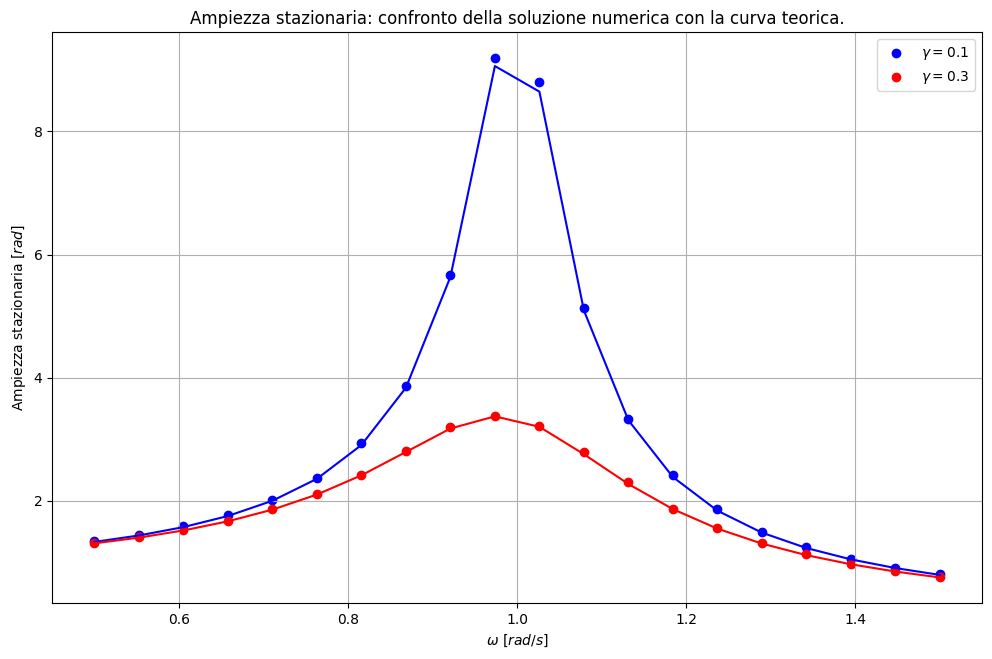

In [45]:
As = np.zeros(len(omegas))
As2 = np.zeros(len(omegas))
As_th = 1 / (np.sqrt((omega0**2 - omegas**2)**2 + (gamma * omegas)**2))
As_th2 = 1 / (np.sqrt((omega0**2 - omegas**2)**2 + (gamma3 * omegas)**2))
for i in range(len(omegas)):
    pos, _ = rk4(x0=0, h=h1, times=t_2, A=1, omega0=1, omega=omegas[i], gamma=0.1, v0=0)
    pos2, _ = rk4(x0=0, h=h1, times=t_2, A=1, omega0=1, omega=omegas[i], gamma=0.3, v0=0)
    As[i] = np.max(pos[int(time_costant2/h1):]) - np.min(pos[int(time_costant2/h1):])
    As2[i] = np.max(pos2[int(time_costant3/h1):]) - np.min(pos2[int(time_costant3/h1):])

plt.scatter(omegas, As/2, label=rf"$\gamma={gamma}$", color="blue")
plt.plot(omegas, As_th, color="blue")
plt.scatter(omegas, As2/2, color="red", label=rf"$\gamma={gamma3}$")
plt.plot(omegas, As_th2, color="red")
plt.xlabel(r"$\omega\ [rad/s]$")
plt.ylabel(r"Ampiezza stazionaria $[rad]$")
plt.grid()
plt.legend()
plt.title("Ampiezza stazionaria: confronto della soluzione numerica con la curva teorica.")
plt.show()

Ora simuliamo il sistema al variare al variare della forzante esterna $\omega$ e creiamo un grafico dell'ampiezza in regime stazionario in funzione della pulsazione della forzante. Notiamo che c'è un valore di $\omega$ in cui si ha il fenomeno della **risonanza**: la pulsazione esterna ha un valore uguale o molto simile alla pulsazione naturale del sistema e quindi le oscillazioni si amplificano. Matematicamente abbiamo che il denominatore diventa più piccolo ($\omega\approx\omega_0 \Rightarrow (\omega^{2}_{0}-\omega^{2})^{2}\approx 0$) e quindi il valore dell'ampiezza aumenta.

Inoltre vediamo che all'aumentare del coefficiente di smorzamento $\gamma$ il picco di risonanza diminuisce, infatti l'ampiezza massima della risonanza è definita come $$A_{max}\approx\frac{A}{\gamma\omega_0}.$$

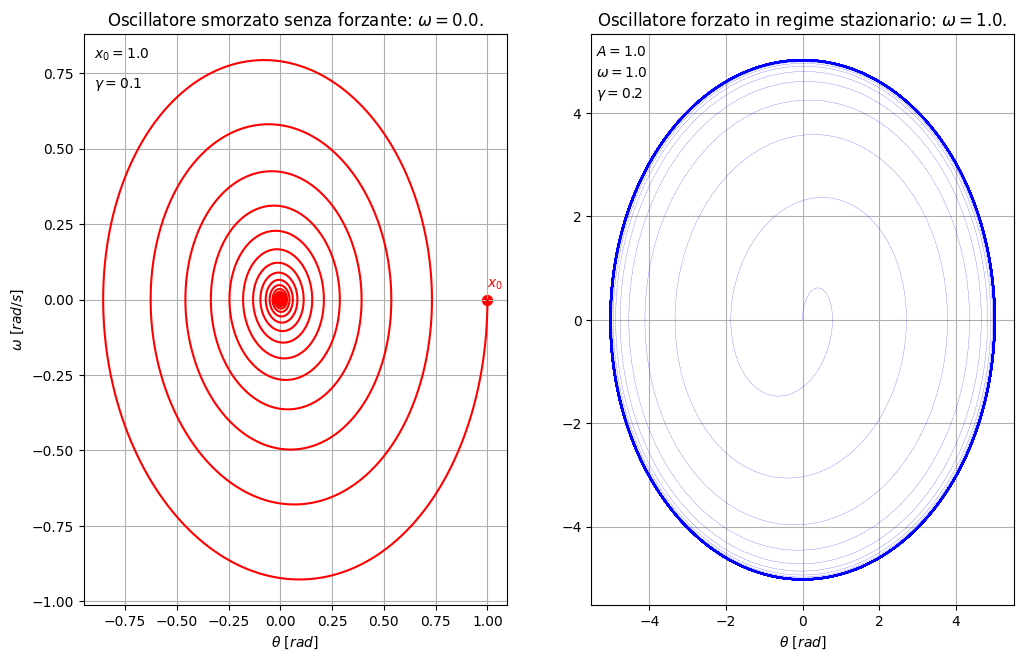

In [44]:
t_3 = np.arange(0, 150, h1)
x1, v1, omega01, omega1, gamma1, A1 = 1.0, 0.0, 1.0, 0.0, 0.1, 0.0
x2, v2, omega02, omega2, gamma2, A2 = 0.0, 0.0, 1.0, 1.0, 0.2, 1.0
time_costant4 = 10*(2/gamma3)
pos, vel = rk4(x0=x1, h=h1, times=t_3, A=A1, omega0=omega01, omega=omega1, gamma=gamma1, v0=v1)
pos2, vel2 = rk4(x0=x2, h=h1, times=t_3, A=A2, omega0=omega02, omega=omega2, gamma=gamma2, v0=v2)

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(pos, vel, color="red", label="Oscillatore smorzato senza forzante")
ax1.scatter(x1, v1, s=50, color="red")
ax1.text(x1, v1 + 4*h1, r"$x_0$", color="red", fontweight="bold")
ax1.set_xlabel(r"$\theta\ [rad]$")
ax1.set_ylabel(r"$\omega\ [rad/s]$")
ax1.grid(True)
ax1.set_title(rf"Oscillatore smorzato senza forzante: $\omega={omega1}$.")
ax1.text(-0.9, 0.8, rf"$x_0={x1}$", fontweight="bold")
ax1.text(-0.9, 0.7, rf"$\gamma={gamma1}$", fontweight="bold")

ax2.plot(pos2[:int(time_costant4/h1)], vel2[:int(time_costant4/h1)], "--", color="blue", lw=0.2)
ax2.plot(pos2[int(time_costant4/h1):], vel2[int(time_costant4/h1):], color="blue", label="Oscillatore forzato in regime stazionario")
ax2.set_xlabel(r"$\theta\ [rad]$")
ax2.grid(True)
ax2.set_title(rf"Oscillatore forzato in regime stazionario: $\omega={omega2}$.")
ax2.text(-5.4, 5.1, rf"$A={A2}$", fontweight="bold")
ax2.text(-5.4, 4.7, rf"$\omega={omega2}$", fontweight="bold")
ax2.text(-5.4, 4.3, rf"$\gamma={gamma2}$", fontweight="bold")

plt.show()

Infine possiamo fare delle considerazione osservando i ritratti di fase dell'oscillatore senza forzante e di quello in regime stazionario. Nel primo caso abbiamo un coefficiente di smorzamento leggermente più piccolo ($\gamma_1=0.1<0.2=\gamma_2$) ma la forzante è nulla: il sistema è dissipativo e infatti abbiamo una spirale che converge al punto fisso stabile rappresentato dall'origine. Nel secondo caso abbiamo una forzante esterna con pulsazione coincidente con quella naturale dell'oscillatore ($\omega=1.0=\omega_0$): l'energia rimane costante in media e quindi dopo un regime transitorio iniziale il sistema si stabilizza in un ciclo limite.